# SARIMAX — previsões e resíduos

**Etapa:** diagnóstico do teste final

As previsões congeladas são comparadas com os valores reais. Em seguida analisamos série residual, distribuição, ACF e Ljung-Box.

**Entrada:** previsões congeladas do teste final  
**Resultado principal:** O Ljung-Box rejeitou em apenas 1 dos 20 lags, uma evidência pontual que não deve ser exagerada.


## 1. Importações, caminhos e funções

In [1]:
from pathlib import Path
import hashlib, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
from IPython.display import display

warnings.filterwarnings("ignore")
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "bases/grupo5/gold_daily_modeling.csv").exists())
BASE_PATH = ROOT / "bases/grupo5/gold_daily_modeling.csv"
OUT = ROOT / "analyses/grupo5/outputs"
OUT.mkdir(parents=True, exist_ok=True)
PROTOCOL_PATH = OUT / "protocol.json"
SEED = 42
np.random.seed(SEED)

def sha256(path):
    return hashlib.sha256(path.read_bytes()).hexdigest()

def load_data():
    df = pd.read_csv(BASE_PATH, parse_dates=["DATE"]).sort_values("DATE").reset_index(drop=True)
    raw_path = ROOT / "bases/grupo5-tratamento/gold_daily_prices.csv"
    raw = pd.read_csv(raw_path, sep=None, engine="python", parse_dates=["DATE"])
    raw["EXPECTED_TARGET"] = pd.to_numeric(raw["VALUE"], errors="coerce").shift(-1)
    raw["TARGET_DATE"] = raw["DATE"].shift(-1)
    target_lookup = raw[["DATE", "TARGET_DATE", "EXPECTED_TARGET"]]
    df = df.merge(target_lookup, on="DATE", how="left", validate="one_to_one")
    assert df["DATE"].is_monotonic_increasing and not df["DATE"].duplicated().any()
    assert "TARGET_UP" not in df.columns and not df.isna().any().any()
    assert np.allclose(df["TARGET"], df["EXPECTED_TARGET"])
    return df.drop(columns="EXPECTED_TARGET")



In [2]:
def load_protocol(require_data_decisions=False):
    if not PROTOCOL_PATH.exists():
        raise RuntimeError("DECISÃO NECESSÁRIA: execute 01_documentacao_bases.ipynb primeiro.")
    protocol = json.loads(PROTOCOL_PATH.read_text(encoding="utf-8"))
    if protocol.get("protocol_version") != 2:
        raise RuntimeError("Protocolo desatualizado: execute novamente 01_documentacao_bases.ipynb.")
    if protocol["dataset_sha256"] != sha256(BASE_PATH):
        raise RuntimeError("A base congelada não corresponde ao hash do protocolo.")
    if require_data_decisions:
        missing = [k for k in ("source", "unit", "cleaning", "features", "seasonal_period") if not protocol["decisions"].get(k)]
        if missing:
            raise RuntimeError(f"DECISÃO NECESSÁRIA: complete as decisões {missing} antes de modelar.")
    return protocol

def save_protocol(protocol):
    PROTOCOL_PATH.write_text(json.dumps(protocol, indent=2, ensure_ascii=False), encoding="utf-8")

def origins(protocol, split):
    return protocol["origins"][split]

def target_dates(df, origin_ids):
    return df["TARGET_DATE"].iloc[origin_ids].to_numpy()


## 2. Previsões, resíduos e diagnóstico

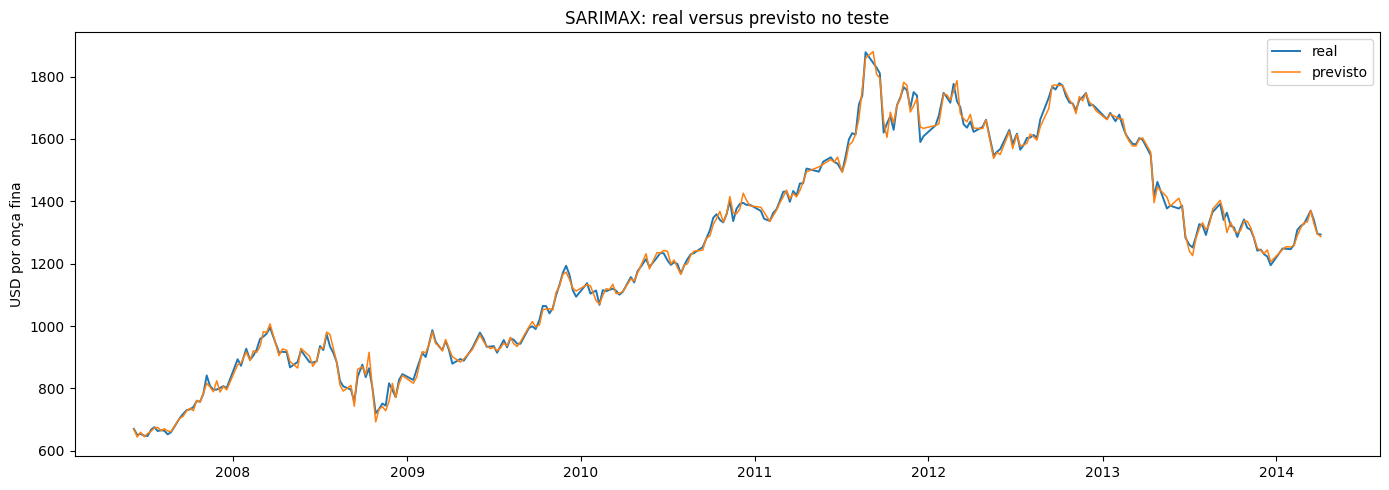

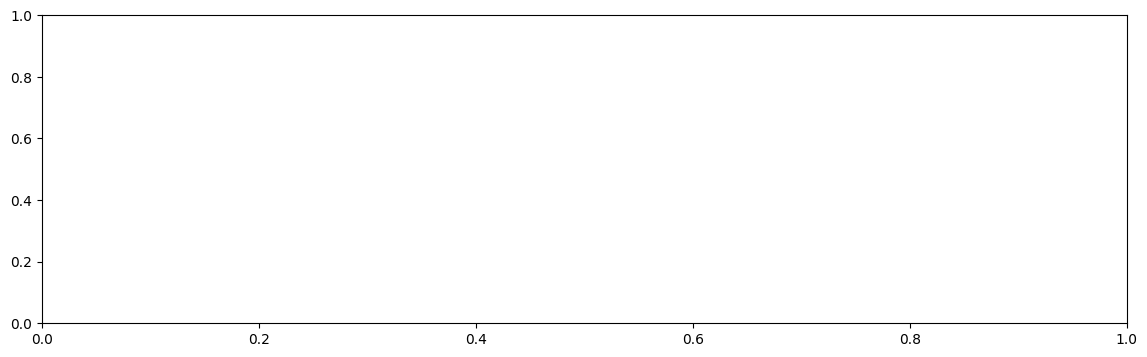

In [3]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

MODEL = "SARIMAX"
protocol = load_protocol(require_data_decisions=True)
params = protocol["decisions"]["accepted_parameters"].get(MODEL)

if params is None:
    raise RuntimeError("Parâmetros finais não encontrados no protocolo.")

predictions = pd.read_csv(OUT / "predictions.csv")
result = (
    predictions[predictions["model"] == MODEL]
    .copy()
    .sort_values("target_date")
    .reset_index(drop=True)
)

if result.empty:
    raise RuntimeError("Execute o walk-forward final deste modelo primeiro.")

result["target_date"] = pd.to_datetime(result["target_date"])
assert len(result) == len(origins(protocol, "test"))
assert np.allclose(result["residual"], result["y_true"] - result["y_pred"])

slug = MODEL.lower()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(result["target_date"], result["y_true"], label="real", linewidth=1.4)
ax.plot(result["target_date"], result["y_pred"], label="previsto", linewidth=1.1)
ax.set_title(f"{MODEL}: real versus previsto no teste")
ax.set_ylabel("USD por onça fina")
ax.legend()
plt.tight_layout()
plt.savefig(
    OUT / f"residual_{slug}_real_vs_previsto.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

fig, ax = plt.subplots(figsize=(14, 4))


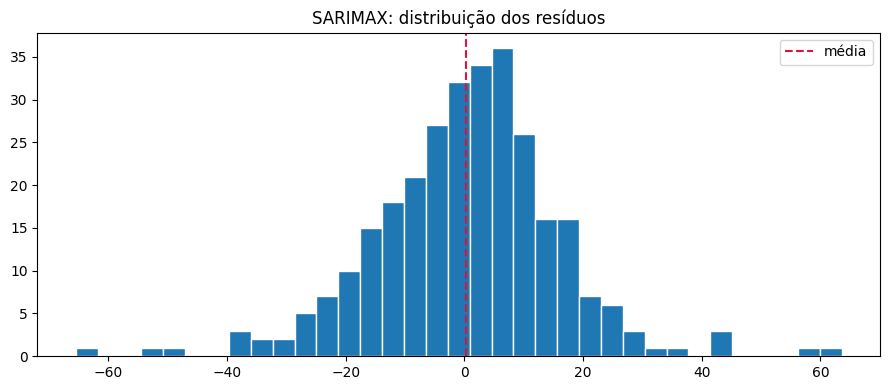

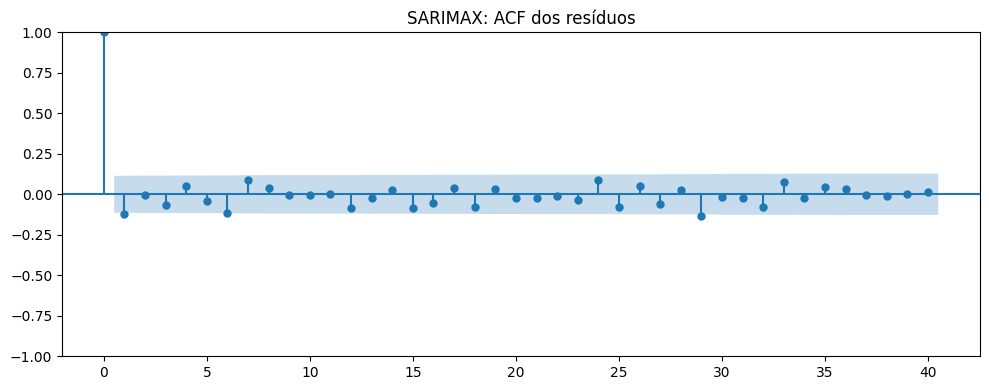

In [4]:
ax.plot(result["target_date"], result["residual"], linewidth=1)
ax.axhline(0, color="black", linestyle="--")
ax.set_title(f"{MODEL}: resíduos fora da amostra")
plt.tight_layout()
plt.savefig(OUT / f"residual_{slug}_serie.png", dpi=150, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(result["residual"], bins=35, edgecolor="white")
ax.axvline(
    result["residual"].mean(),
    color="crimson",
    linestyle="--",
    label="média",
)
ax.set_title(f"{MODEL}: distribuição dos resíduos")
ax.legend()
plt.tight_layout()
plt.savefig(
    OUT / f"residual_{slug}_distribuicao.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(result["residual"], lags=min(40, len(result) // 4), ax=ax)
ax.set_title(f"{MODEL}: ACF dos resíduos")
plt.tight_layout()
plt.savefig(OUT / f"residual_{slug}_acf.png", dpi=150, bbox_inches="tight")
plt.show()

lags = list(range(1, min(20, len(result) // 4) + 1))
ljung_box = acorr_ljungbox(result["residual"], lags=lags, return_df=True)
ljung_box = ljung_box.reset_index(names="lag")
ljung_box.insert(0, "model", MODEL)
ljung_box.insert(0, "dataset", "gold")

ljung_path = OUT / "ljung_box.csv"


In [5]:
old_ljung = (
    pd.read_csv(ljung_path)
    if ljung_path.exists()
    else pd.DataFrame(columns=ljung_box.columns)
)
pd.concat(
    [old_ljung[old_ljung["model"] != MODEL], ljung_box],
    ignore_index=True,
).to_csv(ljung_path, index=False)

summary = pd.DataFrame(
    [
        {
            "model": MODEL,
            "mean_residual": result["residual"].mean(),
            "residual_std": result["residual"].std(),
            "median_residual": result["residual"].median(),
            "max_abs_residual": result["residual"].abs().max(),
        }
    ]
)
summary_path = OUT / "residual_summary.csv"
old_summary = (
    pd.read_csv(summary_path)
    if summary_path.exists()
    else pd.DataFrame(columns=summary.columns)
)
pd.concat(
    [old_summary[old_summary["model"] != MODEL], summary],
    ignore_index=True,
).to_csv(summary_path, index=False)

display(summary)
display(ljung_box)

coefficients = pd.read_csv(OUT / "sarimax_coefficients.csv")
display(coefficients)


,model,mean_residual,residual_std,median_residual,max_abs_residual
0,SARIMAX,0.362117,15.747025,1.31119,65.491651


,dataset,model,lag,lb_stat,lb_pvalue
0,gold,SARIMAX,1,4.202598,0.040362
1,gold,SARIMAX,2,4.203275,0.122256
2,gold,SARIMAX,3,5.471884,0.140330
3,gold,SARIMAX,4,6.345647,0.174779
4,gold,SARIMAX,5,6.916753,0.226906
5,gold,SARIMAX,6,10.786834,0.095192
6,gold,SARIMAX,7,13.295672,0.065224
7,gold,SARIMAX,8,13.809056,0.086880
8,gold,SARIMAX,9,13.809521,0.129264
9,gold,SARIMAX,10,13.812460,0.181719


,dataset,model,feature,coefficient,p_value,split
0,gold,SARIMAX,TREASURY_10Y,-2.327999,5.879437e-07,first_test_origin
1,gold,SARIMAX,FED_FUNDS_RATE,-0.241917,3.720834e-02,first_test_origin
2,gold,SARIMAX,DOW_SIN,0.054023,5.936738e-01,first_test_origin
3,gold,SARIMAX,DOW_COS,0.074671,2.431429e-01,first_test_origin
4,gold,SARIMAX,MONTH_SIN,0.720720,6.081034e-02,first_test_origin
5,gold,SARIMAX,MONTH_COS,0.805544,1.320562e-01,first_test_origin
6,gold,SARIMAX,ma.L1,-0.048313,8.648830e-55,first_test_origin
7,gold,SARIMAX,ma.L2,0.017920,2.831203e-17,first_test_origin
8,gold,SARIMAX,ma.S.L5,0.048330,8.305393e-78,first_test_origin
9,gold,SARIMAX,sigma2,31.647574,0.000000e+00,first_test_origin


## Resumo do diagnóstico

In [ ]:
# Resumo compacto do diagnóstico
diagnostics = pd.read_csv(OUT / "residual_diagnostics_summary.csv")
model_diagnostics = diagnostics[diagnostics["model"] == "SARIMAX"]
display(model_diagnostics[['model', 'media_residuos', 'mediana_residuos', 'desvio_padrao_residuos', 'tested_lags', 'rejected_lags_5pct', 'min_p_value']])

model,media_residuos,mediana_residuos,desvio_padrao_residuos,tested_lags,rejected_lags_5pct,min_p_value
SARIMAX,0.362117,1.31119,15.747025,20,1,0.040362


**Leitura:** média próxima de zero; sem viés médio relevante. uma rejeição isolada em 20 lags; evidência pontual, sem conclusão ampla.

## Interpretação

O Ljung-Box rejeitou em apenas 1 dos 20 lags, uma evidência pontual que não deve ser exagerada.

## Artefatos

Arquivos usados ou produzidos nesta etapa:

- `outputs/predictions.csv`
- `outputs/ljung_box.csv`
- `outputs/residual_sarimax_*.png`